# Feedforward example

This page builds a feedforward neural network (NN) using a [directed
acyclic graph](../concepts/#dag) (DAG). You parse a named edgelist with
`parse_layered()`, write a `PackedLinear` module, train, and map
attributions back to named nodes.

## What does kpnn2 do?

`kpnn2` lets you state an NN architecture as a graph instead of as a
stack of layer sizes. You hand it that graph as an edgelist: each row is
one directed connection, from a `source` node to a `target` node, and
every node carries a name you chose. `kpnn2.parse_layered()` reads that
table and returns a `LayeredSpec`: the named nodes sorted into layers,
together with the packed [hops](../concepts/#hop) that record which
edges arrive at each layer.

A `LayeredSpec` is structure, not a model. You write an ordinary
PyTorch `nn.Module` around it with `PackedLinear`; activations,
head, and training loop stay yours. Attribution methods are yours
as well; `map_node_attributions()` only names a layer tensor.

Here, the graph defines the architecture: the edges decide which weights
exist, and they are the same for every sample. This is useful whenever a
sparsely-connected neural architecture is known before training and can
be represented as named edges.

## Domain example: knowledge-primed neural networks

The key use case is the [knowledge-primed neural
network](../concepts/#kpnn) (KPNN), which gave the package its name. In
a KPNN, prior knowledge encoded as a graph constrains the structure of a
neural network: instead of a fully generic architecture, the model keeps
only the connections that known relationships between named entities
(which are represented by the nodes) support.

The reason to do this is interpretability. Each hidden node corresponds
to one named entity of the domain: in a biological KPNN, a transcription
factor, a kinase, a pathway, or another biological process. An
attribution method that scores such a node is scoring the entity itself
rather than an anonymous unit, so after training, attributions are
available for the internal nodes as well as for the input features,
which is not possible with a dense NN.

The figure below illustrates this idea in a biological setting,
where entities such as genes, transcription factors, kinases,
pathways, and phenotypes can be connected through prior knowledge.

![KPNNs explained](../figures/KPNNs_explained.svg)

**Figure 1.** In a pathway-based KPNN, prior biological knowledge is
encoded directly into the neural network topology. Hidden nodes
represent named biological entities such as receptors, kinases,
transcription factors, or pathways, input nodes for example are
genes, and edges represent curated regulatory or signaling
interactions. This creates a sparsely-connected neural network in
which information flow is constrained by the provided biological
graph, and attribution scores for neural network nodes can be mapped
back to the corresponding biological entities.

KPNN examples include pathway-based models as in [Fortelny and Bock,
2020](https://doi.org/10.1186/s13059-020-02100-5) and ontology-based
models such as in [Elmarakeby et al.,
2021](https://doi.org/10.1038/s41586-021-03922-4).

Biology is the example here, not the boundary: any architecture that
can be written as named edges can be turned into sparsely connected
PyTorch layers and interpreted back in the space of its named
features and nodes.

## The kpnn2 workflow

The workflow is short: an edgelist becomes a [spec](../concepts/#spec),
the spec becomes a module you write, and attributions map back onto the
node names.

The starting point is the edgelist that describes the NN architecture.
Each row is one directed connection between named nodes.
`parse_layered()` ranks those nodes by depth and returns a
`LayeredSpec`. Layer 0 is the inputs. Each later layer has one hop: the
set of all edges that arrive there.

A hop is everything that arrives at one layer: every edge whose target
is a node of that layer, whichever layer it left. A hop does not store a
dense weight matrix. It stores those edges as
[two parallel index lists](../concepts/#packed-indices),
`source_index` and `target_index`, one entry per live connection: pair
`i` says that column `source_index[i]` feeds row `target_index[i]`. The
rows are the units of the target layer. The columns are that hop's
source layers concatenated, the axis `gather_hop_inputs()` assembles.

One hop is one layer of the model. `PackedLinear` takes those two index
lists and gives every pair its own trainable scalar, so applying the hop
applies every parent of the layer at once. `spec.hops[i]` is the hop
into layer `i + 1`, so there is one hop per layer after the first, and
`len(spec.hops)` is one less than the number of layers.

An edge that jumps a layer does not get its own hop. It is still a
packed pair in the hop of its target, next to the adjacent parents of
that layer. There is no second mechanism for
[skips](../concepts/#skip-edge) (see [Skip edges](../skip-edges/)).

The model is a normal PyTorch `nn.Module`. You choose activations,
dropout, task-specific heads, losses, optimizers, and the training
loop.

After training, run any attribution method you like (this notebook
uses Captum). Then `map_node_attributions()` labels a layer tensor
as an xarray DataArray with the node names from the original
edgelist. `kpnn2` does not import Captum.

This notebook shows that feedforward workflow:

1. represent a model architecture as an edgelist
2. parse it into a `LayeredSpec` and write a `PackedLinear` module
3. align named inputs, train with ordinary PyTorch
4. attribute the trained model back to named features and nodes

The example uses biological names because KPNNs are a natural
application area, but the same workflow applies to other domains
where the architecture can be expressed as a graph.


## Installation

Install `kpnn2` from PyPI with:

```bash
pip install kpnn2
```

The later interpretation cells also need Captum, which is not a
`kpnn2` dependency:

```bash
pip install captum
```

Graphviz is used only to draw the toy graph in this notebook.


## Imports


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [ ]:
import random

from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Step 1: define a prior-knowledge edgelist

The architecture comes first, as a table of edges. A real prior
comes from a curated database; here a handful of rows stands in for
one.

`kpnn2` expects an edgelist with two required columns, `source` and
`target`, one row per directed connection. Extra columns are ignored.
`parse_layered()` sorts nodes into layers by depth, which exists only
without feedback, so it requires the graph to be a DAG and raises on a
cycle. A graph with feedback loops goes through the other
[parser](../concepts/#parser), `parse_adjacency()`, shown in the [Cyclic
graph example](../cyclic-graph-example/).

Here we define a small feedforward biological graph with two clearly
separated branches:

- a **signal branch**, connected to informative input features
- a **noise branch**, connected to uninformative input features

Keeping the branches apart is what makes the later interpretation
steps easy to judge: after training, informative features and their
connected hidden nodes should receive stronger attributions than the
uninformative branch.


In [ ]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
            "tf_signal",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
        ],
        "target": [
            "tf_signal",
            "tf_signal",
            "tf_signal",
            "tf_noise",
            "tf_noise",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
            "output_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise
6,tf_signal,kinase_signal
7,tf_noise,kinase_noise
8,kinase_signal,output_1
9,kinase_noise,output_1


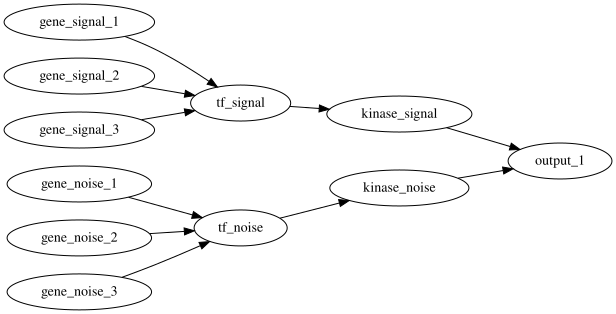

In [ ]:
# Visualize the graph

dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
layer_1_nodes = ["tf_signal", "tf_noise"]
layer_2_nodes = ["kinase_signal", "kinase_noise"]
output_nodes = ["output_1"]

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in input_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_1_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_2_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in output_nodes:
        s.node(node, node)

for _, row in edgelist.iterrows():
    dot.edge(row["source"], row["target"])

dot

## Step 2: parse the edgelist and write a module

Parsing turns the table into the structure a module can be built
from. `parse_layered(...)` returns a `LayeredSpec`: named nodes by
layer, one packed hop per layer after the first, and skip-edge
metadata. It stops there and does not return an `nn.Module`.

Building the network is your job: one `PackedLinear` per hop, with your
own activations and task head around them. This spec has three hops and
no skip edges, so each hop reads only the layer below it. When an edge
jumps a layer, its hop reads more than one source layer and
`gather_hop_inputs()` concatenates them (see [Skip
edges](../skip-edges/)).


In [ ]:
spec = kpnn2.parse_layered(edgelist)
spec.input_nodes, spec.hidden_nodes, spec.output_nodes

(('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'),
 ('kinase_noise', 'kinase_signal', 'tf_noise', 'tf_signal'),
 ('output_1',))

### Inspect the LayeredSpec

The three cells below read the parsed structure.
`spec.layer_nodes[i]` is the names at depth `i`, so the printed
tuples are the layers of the drawing above. `spec.hops[i]` is the
fixed packed connectivity entering layer `i + 1`, and it holds
every edge that arrives there, which is why the
`(out_features, in_features)` pairs are the shapes the three
`PackedLinear` layers will have. `spec.skips` is empty for this
graph, so every hop reads exactly the layer below it, and the
`forward()` below can pass `x` into `lin0`, that result into
`lin1`, and so on.


In [ ]:
spec.layer_nodes

(('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'),
 ('tf_noise', 'tf_signal'),
 ('kinase_noise', 'kinase_signal'),
 ('output_1',))

In [ ]:
[(hop.out_features, hop.in_features) for hop in spec.hops]

[(2, 6), (2, 2), (1, 2)]

In [ ]:
spec.skips

()

The model is a small `nn.Module`, and only its three `PackedLinear`
layers come from the spec, one per hop; we name them `lin0`, `lin1`,
and `lin2`. The graph ends in a single node, so we add a
one-dimensional linear head that outputs a single logit.

Two decisions about ReLU are worth stating. ReLU is applied after
every hop except the last graph hop: `output_1` is a scalar
bottleneck, and applying ReLU to it can suppress gradients if the
output is negative. ReLU can also zero a whole branch if that branch
starts with negative pre-activations. Both branches of this toy
graph should be able to learn, so we initialize each `PackedLinear`
bias to `1.0`. Without that, the swap control later can fail even
when the labels sit on the noise-branch genes.


In [ ]:
class KPNN(nn.Module):
    def __init__(self, spec: kpnn2.LayeredSpec):
        super().__init__()
        self.spec = spec
        self.lin0 = kpnn2.PackedLinear(
            spec.hops[0].source_index,
            spec.hops[0].target_index,
            spec.hops[0].out_features,
            spec.hops[0].in_features,
            identity=spec.fingerprint,
        )
        self.lin1 = kpnn2.PackedLinear(
            spec.hops[1].source_index,
            spec.hops[1].target_index,
            spec.hops[1].out_features,
            spec.hops[1].in_features,
            identity=spec.fingerprint,
        )
        self.lin2 = kpnn2.PackedLinear(
            spec.hops[2].source_index,
            spec.hops[2].target_index,
            spec.hops[2].out_features,
            spec.hops[2].in_features,
            identity=spec.fingerprint,
        )
        self.head = nn.Linear(1, 1)
        for layer in (self.lin0, self.lin1, self.lin2):
            if layer.bias is not None:
                nn.init.constant_(
                    layer.bias,
                    1.0,
                )

    def forward(self, x):
        h0 = F.relu(self.lin0(x))
        h1 = F.relu(self.lin1(h0))
        h2 = self.lin2(h1)
        return self.head(h2)


model = KPNN(spec)
model

KPNN(
  (lin0): PackedLinear(in_features=6, out_features=2, nnz=6, bias=True)
  (lin1): PackedLinear(in_features=2, out_features=2, nnz=2, bias=True)
  (lin2): PackedLinear(in_features=2, out_features=1, nnz=2, bias=True)
  (head): Linear(in_features=1, out_features=1, bias=True)
)

Each hop is a `PackedLinear`, which keeps one trainable scalar per [live
edge](../concepts/#live-edge) — an edge the graph actually has — instead
of a dense `(out, in)` matrix: `layer.weight` is one-dimensional, of
length `nnz`. `MaskedLinear(hop.to_mask())` remains the dense hatch when
that rectangle fits.


Weights alone cannot describe this model, because a `state_dict`
carries numbers and no node names. A checkpoint is therefore
`spec.to_dict()` plus `state_dict`, which is what the cell below
saves and rebuilds from. Save `state_dict`, not the module:
`torch.save(spec)` pickles the dataclass and will break when spec
fields move, so `to_dict()` is the interchange. Alphabetical unit
identity is unchanged. On load, `index_digest` checks the packed
indices and `identity=spec.fingerprint` catches a rename that
leaves those indices unchanged. There is no `layout=` parser flag,
so the reload names `LayeredSpec.from_dict` or
`AdjacencySpec.from_dict` explicitly.


In [ ]:
import tempfile

path = tempfile.NamedTemporaryFile(
    suffix=".pt",
    delete=False,
).name
payload = {
    "spec": spec.to_dict(),
    "state_dict": model.state_dict(),
}
torch.save(
    payload,
    path,
)
blob = torch.load(
    path,
    weights_only=False,
)
spec = kpnn2.LayeredSpec.from_dict(blob["spec"])
# or AdjacencySpec.from_dict when blob["spec"]["layout"]
# is "adjacency"
model = KPNN(spec)
model.load_state_dict(blob["state_dict"])

<All keys matched successfully>

## Step 3: simulate data and align it to the model

PyTorch sees column positions, not names, so the tensor handed to
the model must follow the exact order stored in `spec.input_nodes`.
In practice, input data often comes from a DataFrame where features
are named but not necessarily ordered like the model input layer.

`align_inputs()` closes that gap: it uses the `LayeredSpec` to
reorder named input features into the dense `float32` tensor the
model expects. This prevents silent feature-order mismatches
between the data and the architecture.

The data is simulated here so that the interpretation steps have a
known answer. The `gene_signal_*` features carry class information,
while the `gene_noise_*` features are uninformative. We achieve this
by sampling every feature from a normal distribution: the
`gene_signal_*` features use a different mean in each class, so
there is a real class difference the model can exploit, while the
`gene_noise_*` features use the same mean in both classes, so any
apparent difference between the classes is only random sampling
variation.


In [ ]:
# Simulate the training and test data
rng = np.random.default_rng(42)

informative_features = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]

noise_features = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]

all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]
    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")
    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)
x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

display(x_train_df.head())
display(y_train.head())
display(x_test_df.head())
display(y_test.head())

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,-0.695943,-0.223859,0.242497,-1.139429,-0.481241,1.437777
1,3.068472,2.232878,2.234401,-0.712102,1.370541,-0.484030
2,-0.471525,0.263717,0.052467,0.288917,1.244947,-0.431339
3,0.941464,1.874991,3.481456,-0.109727,-0.035611,-1.364742
4,-0.926576,-0.389810,-1.376686,-1.119536,0.447814,0.058274


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,-0.306566,-0.593220,-0.325545,-0.491747,0.892856,-0.774510
1,1.687645,3.358121,2.508079,0.619105,-1.160912,0.032370
2,-0.379687,0.376948,-1.126988,1.191390,-0.696212,0.223967
3,0.466178,-0.376212,-0.507105,-1.567177,0.388474,-1.759816
4,1.239810,2.577403,2.046557,-1.466186,-1.093737,1.026906


0    0
1    1
2    0
3    0
4    1
Name: label, dtype: int64

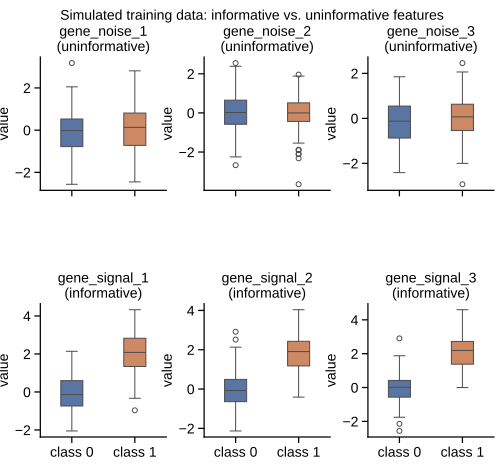

In [ ]:
# Visualize the simulated training data

plot_df = x_train_df.copy()
plot_df["label"] = y_train.values
plot_df["class"] = plot_df["label"].map({0: "class 0", 1: "class 1"})

long_df = plot_df.melt(
    id_vars=["label", "class"],
    value_vars=spec.input_nodes,
    var_name="feature",
    value_name="value",
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}
long_df["feature_type"] = long_df["feature"].map(feature_type_map)

n_cols = 3
g = sns.catplot(
    data=long_df,
    x="class",
    y="value",
    col="feature",
    col_wrap=n_cols,
    hue="class",
    kind="box",
    width=0.35,
    sharey=False,
    height=3.3,
    aspect=1.0,
    legend=False,
)
g.fig.set_size_inches(_FIG_W, g.fig.get_figheight())
g.fig.suptitle(
    "Simulated training data: informative vs. uninformative features",
    fontsize=_FONT_SIZE,
    y=0.98,
)
g.fig.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.08,
    right=0.98,
    hspace=0.85,
    wspace=0.3,
)
for ax, feature in zip(g.axes.flat, spec.input_nodes):
    feature_type = feature_type_map[feature]
    ax.set_title(f"{feature}\n({feature_type})")
    ax.set_xlabel("")
    ax.set_ylabel("value")
    _style_ax(ax)
g.fig.patch.set_facecolor("none")
plt.show()

In [ ]:
x_train = kpnn2.align_inputs(
    x_train_df,
    spec,
)
x_test = kpnn2.align_inputs(
    x_test_df,
    spec,
)
x_train.shape, x_test.shape

(torch.Size([200, 6]), torch.Size([100, 6]))

To verify that alignment is based on feature names, we deliberately
reverse the DataFrame columns and align the shuffled DataFrame
again. The result is identical to the original aligned tensor.


In [ ]:
# Alignment is name-based, not position-based.
# Even if the DataFrame columns are shuffled, the aligned tensor
# is unchanged.

shuffled_columns = list(reversed(spec.input_nodes))
x_train_df_shuffled = x_train_df[shuffled_columns]
x_train_from_shuffled = kpnn2.align_inputs(
    x_train_df_shuffled,
    spec,
)
torch.allclose(x_train, x_train_from_shuffled)

True

<div class="admonition warning">
<p class="admonition-title">Keep the LayeredSpec input order</p>
<p>PyTorch never sees feature names. Column <code>i</code> is
whatever name is in <code>spec.input_nodes[i]</code>. Keep this
<code>model</code> with this <code>spec</code>, and build every
train/val/test tensor with
<code>align_inputs(..., spec)</code>.</p>
<p>Do not pass <code>df.values</code> (or any hand-built array)
into the model: if the width is right, training still runs and the
features are silently wired to the wrong nodes. Extra columns and
shuffled DataFrame order are fine; renaming required columns is
not.</p>
</div>


## Step 4: train the model in PyTorch

Training is where `kpnn2` steps back. The `KPNN` module is still a
normal PyTorch module, so it trains with ordinary PyTorch
components such as loss functions, optimizers, and training loops,
none of which the package provides.

Below is a minimal training loop that shows how the packed
structural core and the added head fit directly into a standard
PyTorch workflow.


Loss before first update: 0.7193
Loss after final update:  0.1264


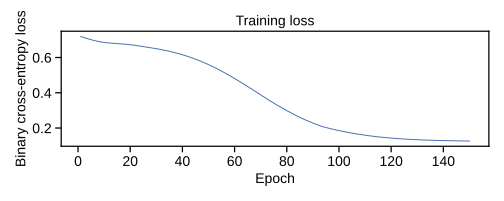

In [ ]:
# Train the model with the simulated data

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()

for epoch in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

_new_fig(2.8)
plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Step 5: feature-level interpretation

The first question to ask a trained KPNN is which input features
drove its predictions. Any attribution method applies, because the
model is plain PyTorch; for this example, we use Captum
`IntegratedGradients` on the trained module. `kpnn2` does not wrap
Captum.

The result is a tensor of shape `(n_test, n_input_nodes)` whose
columns follow `spec.input_nodes`, the same order as
`align_inputs`, so the scores line up with the feature names. Those
values are signed Captum scores. The `mean_abs_attribution` column
below is computed with `.abs()` for ranking.

Simulation gives this step a ground truth: the `gene_signal_*`
features were generated with different class means, whereas the
`gene_noise_*` features were not. The recovered attributions need
not match those class mean differences exactly, but the informative
features should generally receive larger magnitudes than the
uninformative ones. That is the sanity check the table and plot
below are for.


In [ ]:
from captum.attr import IntegratedGradients

model.eval()
ig = IntegratedGradients(model)
feature_tensor = ig.attribute(
    x_test,
    target=0,
)
feature_attr = pd.DataFrame(
    feature_tensor.detach().cpu().numpy(),
    columns=spec.input_nodes,
)
feature_attr.head()

,gene_noise_1,gene_noise_2,gene_noise_3,gene_signal_1,gene_signal_2,gene_signal_3
0,0.196101,0.668750,0.202322,-0.497082,-1.020986,-1.048680
1,-0.123444,-0.434762,-0.004228,1.538032,3.248478,4.541016
2,-0.252323,-0.276943,-0.031072,-0.615644,0.648761,-3.630373
3,0.624964,0.290968,0.459710,0.755886,-0.647495,-1.633541
4,0.584690,-0.819210,-0.268255,1.429201,3.153695,4.686942


In [ ]:
# Summarize feature attributions and compare them to the simulated
# signal

class_mean_diff = (
    x_test_df.loc[y_test == 1].mean() - x_test_df.loc[y_test == 0].mean()
)

feature_summary = pd.DataFrame(
    {
        "feature": spec.input_nodes,
        "abs_class_mean_difference": (
            class_mean_diff.abs().reindex(spec.input_nodes).values
        ),
        "mean_abs_attribution": (
            feature_attr.abs().mean(axis=0).reindex(spec.input_nodes).values
        ),
        "mean_signed_attribution": (
            feature_attr.mean(axis=0).reindex(spec.input_nodes).values
        ),
    }
)
feature_summary["feature_type"] = feature_summary["feature"].map(
    feature_type_map
)
feature_summary

,feature,abs_class_mean_difference,mean_abs_attribution,mean_signed_attribution,feature_type
0,gene_noise_1,0.223047,0.307921,0.125116,uninformative
1,gene_noise_2,0.251055,0.471398,0.035299,uninformative
2,gene_noise_3,0.089079,0.187094,0.033711,uninformative
3,gene_signal_1,2.086208,1.851277,1.198257,informative
4,gene_signal_2,1.477629,1.977181,1.316618,informative
5,gene_signal_3,1.617368,3.452763,2.320762,informative


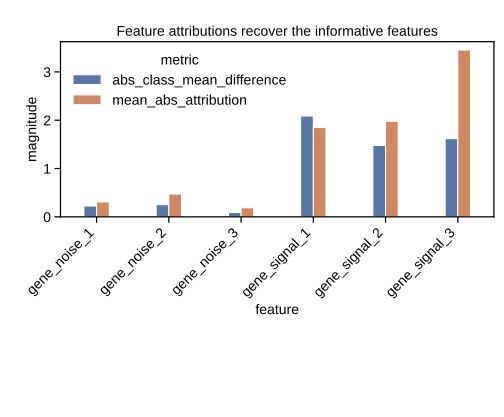

In [ ]:
# Plot recovered attributions against the true simulated signal

plot_df = feature_summary.melt(
    id_vars=["feature", "feature_type"],
    value_vars=[
        "abs_class_mean_difference",
        "mean_abs_attribution",
    ],
    var_name="metric",
    value_name="value",
)

_new_fig(5.8)
sns.barplot(
    data=plot_df,
    x="feature",
    y="value",
    hue="metric",
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    frameon=False,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("magnitude")
plt.title("Feature attributions recover the informative features")
plt.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.48,
    top=0.9,
)
plt.show()

## Step 6: node-level interpretation

Node-level interpretation is what the named NN architecture buys you:
the same kind of scores, but on the internal nodes of the graph. This is
often the most interesting interpretation level, because it helps show
which hidden biological entities in the network carry signal for the
task.

For this example, we use Captum `LayerConductance` on each
`PackedLinear` hop. `map_node_attributions()` then labels the
`(batch, n_units)` tensor as an xarray DataArray with
`spec.layer_nodes[layer]` on the `node` axis. `PackedLinear` hop
`i` produces the activations at layer `i + 1`, so we pass
`layer=i + 1`. Input features have no hop and are not included; use
the feature table from Step 5 for inputs. The mapper itself is
walked through in
[Mapping attributions](../map-node-attributions/).

Those values are signed. The plots below use `.abs()` so we can
compare overall importance when signs would otherwise cancel.
Because this dataset was simulated with informative and
uninformative feature groups, we expect nodes on the informative
branch of the graph to tend to show larger attribution magnitudes
than nodes on branches driven mainly by noise.


In [ ]:
from captum.attr import LayerConductance

node_attr_by_layer = {}
for hop, layer_module in enumerate((model.lin0, model.lin1, model.lin2)):
    conductor = LayerConductance(
        model,
        layer_module,
    )
    attributions = conductor.attribute(
        x_test,
        target=0,
    )
    layer_index = hop + 1
    node_attr_by_layer[layer_index] = kpnn2.map_node_attributions(
        attributions=attributions,
        spec=spec,
        layer=layer_index,
    )

for layer_index, da in node_attr_by_layer.items():
    print("layer", layer_index, spec.layer_nodes[layer_index])
    display(da.to_pandas().head())

layer 1 ('tf_noise', 'tf_signal')


node,tf_noise,tf_signal
observation,,
0,1.066010,-2.563950
1,-0.596108,9.798621
2,-0.591162,-3.593335
3,1.374142,-1.523488
4,-0.502226,9.568937


layer 2 ('kinase_noise', 'kinase_signal')


node,kinase_noise,kinase_signal
observation,,
0,1.066009,-2.563950
1,-0.571728,9.497080
2,-0.571766,-3.593335
3,1.374142,-1.523488
4,-0.502226,9.499016


layer 3 ('output_1',)


node,output_1
observation,
0,-1.497941
1,8.850821
2,-4.165101
3,-0.149347
4,8.922259


One score per node and test sample is more than can be read
directly, so we now summarize the attributions across the test set.

For each node, we compute:

- the mean attribution
- the mean absolute attribution

The mean absolute attribution is often especially useful, because
it reflects overall importance even when positive and negative
values cancel out on average. That `.abs()` step is a display
choice; `map_node_attributions()` keeps the signed scores
as xarray.


In [ ]:
node_summary_frames = []
for layer_index, da in node_attr_by_layer.items():
    layer_df = da.to_pandas()
    layer_summary = pd.DataFrame(
        {
            "layer": layer_index,
            "node": layer_df.columns,
            "mean_attribution": layer_df.mean(axis=0).values,
            "mean_abs_attribution": layer_df.abs().mean(axis=0).values,
        }
    )
    node_summary_frames.append(layer_summary)

node_summary = (
    pd.concat(node_summary_frames, ignore_index=True)
    .sort_values(
        ["layer", "mean_abs_attribution"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)
node_summary

,layer,node,mean_attribution,mean_abs_attribution
0,1,tf_signal,4.899605,6.223583
1,1,tf_noise,0.187428,0.599412
2,2,kinase_signal,4.853464,6.177442
3,2,kinase_noise,0.192512,0.594327
4,3,output_1,5.023368,6.271207


The following plot shows the mean absolute attribution for each
internal node across the test set. Magnitude is used here only so
the ranking is easy to read.


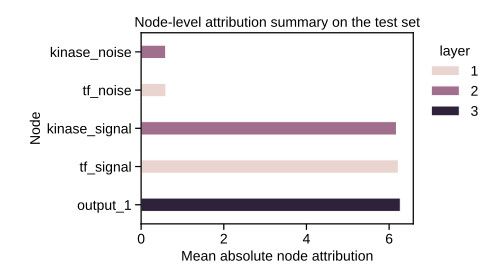

In [ ]:
plot_df = node_summary.sort_values(
    "mean_abs_attribution",
    ascending=True,
)

_new_fig(3.8)
sns.barplot(
    data=plot_df,
    x="mean_abs_attribution",
    y="node",
    hue="layer",
    dodge=False,
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Node-level attribution summary on the test set")
plt.subplots_adjust(
    left=0.28,
    right=0.82,
    bottom=0.18,
    top=0.88,
)
plt.show()

## Control: swap which branch is informative

The main example already pairs a positive and negative control in
one experiment: the signal branch lights up and the noise branch
stays low. The architecture is symmetric, so that contrast is
fairly strong on its own.

One remaining check is a **swap control**: put class signal on the
former noise genes instead. If attribution tracks the data rather
than branch identity, importance should move to `tf_noise` /
`kinase_noise`, while the former signal branch should drop.

This section is intentionally short: same graph, swapped
informative features, retrain, and compare node importance.


,node,main_example,swap_control,branch
3,tf_noise,0.599412,5.578154,noise branch
0,kinase_noise,0.594327,5.556711,noise branch
2,output_1,6.271207,5.514375,output
1,kinase_signal,6.177442,0.138877,signal branch
4,tf_signal,6.223583,0.138877,signal branch


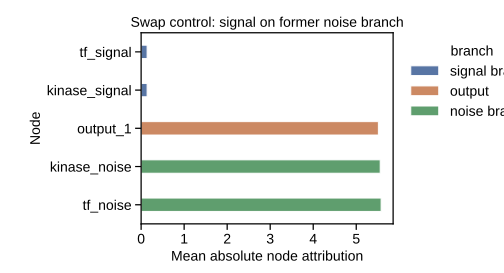

In [ ]:
# Control: class signal on the former noise genes.
torch.manual_seed(42)
rng_swap = np.random.default_rng(42)

swap_informative = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
swap_uninformative = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]
swap_features = swap_informative + swap_uninformative


def simulate_swap(n_per_class, rng):
    n_inf = len(swap_informative)
    n_noise = len(swap_uninformative)
    x0 = np.concatenate(
        [
            rng.normal(0.0, 1.0, size=(n_per_class, n_inf)),
            rng.normal(0.0, 1.0, size=(n_per_class, n_noise)),
        ],
        axis=1,
    )
    x1 = np.concatenate(
        [
            rng.normal(2.0, 1.0, size=(n_per_class, n_inf)),
            rng.normal(0.0, 1.0, size=(n_per_class, n_noise)),
        ],
        axis=1,
    )
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    perm = rng.permutation(len(y))
    return (
        pd.DataFrame(x[perm], columns=swap_features),
        pd.Series(y[perm], name="label"),
    )


x_swap_train_df, y_swap_train = simulate_swap(100, rng_swap)
x_swap_test_df, y_swap_test = simulate_swap(50, rng_swap)

swap_spec = kpnn2.parse_layered(edgelist)
swap_model = KPNN(swap_spec)
x_swap_train = kpnn2.align_inputs(
    x_swap_train_df,
    swap_spec,
)
y_swap_tensor = torch.tensor(
    y_swap_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    swap_model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()
swap_model.train()
for _ in range(150):
    optimizer.zero_grad()
    loss = loss_fn(swap_model(x_swap_train), y_swap_tensor)
    loss.backward()
    optimizer.step()

swap_model.eval()
x_swap_test = kpnn2.align_inputs(
    x_swap_test_df,
    swap_spec,
)
swap_frames = []
for hop, layer_module in enumerate(
    (swap_model.lin0, swap_model.lin1, swap_model.lin2)
):
    conductor = LayerConductance(
        swap_model,
        layer_module,
    )
    attributions = conductor.attribute(
        x_swap_test,
        target=0,
    )
    layer_df = kpnn2.map_node_attributions(
        attributions=attributions,
        spec=swap_spec,
        layer=hop + 1,
    ).to_pandas()
    swap_frames.append(layer_df)

swap_node_attr = pd.concat(swap_frames, axis=1)
swap_summary = (
    swap_node_attr.abs()
    .mean(axis=0)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)
branch_map = {
    "tf_signal": "signal branch",
    "kinase_signal": "signal branch",
    "tf_noise": "noise branch",
    "kinase_noise": "noise branch",
    "output_1": "output",
}
swap_summary["branch"] = swap_summary["node"].map(branch_map)

main_internal = (
    node_summary.loc[
        node_summary["node"].isin(branch_map),
        ["node", "mean_abs_attribution"],
    ]
    .groupby("node", as_index=False)["mean_abs_attribution"]
    .max()
    .rename(columns={"mean_abs_attribution": "main_example"})
)
compare = main_internal.merge(
    swap_summary[["node", "mean_abs_attribution", "branch"]],
    on="node",
    how="outer",
).rename(columns={"mean_abs_attribution": "swap_control"})
compare = compare.sort_values("swap_control", ascending=False)
display(compare)

_new_fig(3.8)
sns.barplot(
    data=swap_summary.sort_values(
        "mean_abs_attribution",
        ascending=True,
    ),
    x="mean_abs_attribution",
    y="node",
    hue="branch",
    dodge=False,
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Swap control: signal on former noise branch")
plt.subplots_adjust(
    left=0.28,
    right=0.78,
    bottom=0.18,
    top=0.88,
)
plt.show()

If the swap worked, mean absolute attribution should concentrate on
the noise-branch nodes (`tf_noise`, `kinase_noise`) rather than the
signal-branch nodes (`tf_signal`, `kinase_signal`). That confirms
the quiet noise branch in the main example reflected uninformative
inputs, not a structural preference for the left-hand pathway.